In [1]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed
from src.utils.experiment_utils import find_experiment_by_name

# Importar as funções
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

from src.result_analysis.metrics import (
    compute_flow_metrics,
    print_metrics_summary
)

from src import save_predictions, save_plot
from src.utils.experiment_utils import convert_predictions_to_df

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_inference, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)


# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed_inference"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed_inference


In [2]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
horizon = data_config["horizon"]
reference_dates = data_config["reference_dates"]
experiment_name = data_config['experiment_name']

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [3]:
# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined_inference.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...
✓ Dados carregados: 51 dias
  Período: 2026-02-15 a 2026-04-06
  Colunas: 67


#### Preenchimento de Nans no Dataset de features temporais

In [4]:
def calculate_temporal_features(dates):
    """Calcula features temporais para um conjunto de datas."""
    # Converter para numpy datetime
    dates_np = dates.to_numpy().astype('datetime64[D]')
    
    # Dia do ano (1-366)
    day_of_year = (dates_np - dates_np.astype('datetime64[Y]')).astype(int) + 1
    
    # Mês (1-12)
    month = dates.month.to_numpy()
    
    # Normalizar e calcular seno/cosseno
    day_angle = 2 * np.pi * day_of_year / 366
    month_angle = 2 * np.pi * (month - 1) / 12
    
    return {
        'day_sin': np.sin(day_angle),
        'day_cos': np.cos(day_angle),
        'month_sin': np.sin(month_angle),
        'month_cos': np.cos(month_angle)
    }

# Identificar linhas com NaN nas features temporais
temporal_cols = ['day_sin', 'day_cos', 'month_sin', 'month_cos']
mask_missing = combined_df[temporal_cols].isna().any(axis=1)

if mask_missing.any():
    print(f"⚠️ {mask_missing.sum()} linhas sem features temporais")
    
    # Calcular features temporais para essas linhas
    missing_dates = combined_df[mask_missing].index
    temporal_feats = calculate_temporal_features(missing_dates)
    
    # Preencher
    for col, values in temporal_feats.items():
        combined_df.loc[mask_missing, col] = values
    
    print("✅ Features temporais calculadas para datas futuras")
    
    # Verificar
    print("\nPrimeiras 5 linhas do período de forecast (após correção):")
    print(combined_df[temporal_cols].iloc[30:35])
else:
    print("✅ Todas as linhas têm features temporais")

✅ Todas as linhas têm features temporais


#### ZERAR COLUNAS DE P PARA TESTE

In [5]:
'''# Selecionar colunas que contêm 'precipitation' no nome
precipitation_cols = [col for col in combined_df.columns if 'precipitation' in col]

# Zerar os valores dessas colunas
combined_df[precipitation_cols] = 0'''

"# Selecionar colunas que contêm 'precipitation' no nome\nprecipitation_cols = [col for col in combined_df.columns if 'precipitation' in col]\n\n# Zerar os valores dessas colunas\ncombined_df[precipitation_cols] = 0"

### Importação do Modelo e Criação do Dataset

In [6]:
## Caso queira passar manualmente o caminho para um modelo
#model_path = root_folder / "models/model_freerun_reducemaxgate.pth"

# Detecta automaticamente o último experimento pelo nome definido no data_config
exp_path = find_experiment_by_name(experiment_name)
model_dir = exp_path / "model"
pth_files = sorted(model_dir.glob("*.pth"))
if not pth_files:
    raise FileNotFoundError(f"Nenhum modelo encontrado em {model_dir}. Salve o modelo com save_checkpoint primeiro.")
model_path = pth_files[0]

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print(f"Carregando checkpoint: {model_path}")
model, meta = load_checkpoint(model_path, device=DEVICE)

Carregando checkpoint: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_009_Improve_model_performance_autoregressive_climate_skip_gate\model\model_autoreg_climateskip.pth
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multia

In [7]:
# Recriar dataset com dados corrigidos
ds_inference = create_dataset_for_inference(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=api_k_list,
    static_keys=static_keys,
    reference_dates=reference_dates,
    forcings="P",
    meta=meta
)

# Copiar scalers de dP_obs_dt para dP_forecast_dt
from src.data.data_structures import Scaler

for station in [10100000, 13150000, 14100000]:
    obs_key = f'dP_obs_dt_{station}'
    fc_key = f'dP_forecast_dt_{station}'
    
    if obs_key in meta['climate_scalers']:
        # Copiar scaler de obs para forecast
        ds_inference.climate_scalers[fc_key] = meta['climate_scalers'][obs_key]
        print(f"✅ {fc_key}: copiado de {obs_key}")
        print(f"   mean={meta['climate_scalers'][obs_key].mean:.4f}, std={meta['climate_scalers'][obs_key].std:.4f}")
    else:
        print(f"❌ {obs_key} não encontrado!")

print("\n✅ Scalers de dP_forecast_dt configurados!")

# Injetar scalers
ds_inference.flow_scalers = meta["flow_scalers"]
ds_inference.climate_scalers = meta["climate_scalers"]
ds_inference.static_scalers = meta["static_scalers"]

# Copiar scalers de dP_obs_dt para dP_forecast_dt
for station in [10100000, 13150000, 14100000]:
    obs_key = f'dP_obs_dt_{station}'
    fc_key = f'dP_forecast_dt_{station}'
    if obs_key in meta['climate_scalers']:
        ds_inference.climate_scalers[fc_key] = meta['climate_scalers'][obs_key]

# Testar sample
sample = ds_inference[0]

print("\n🔬 INSPEÇÃO FINAL:")
print(f"encoder_dyn: Tem NaN? {torch.isnan(sample.encoder_dyn).any().item()}")
print(f"decoder_dyn: Tem NaN? {torch.isnan(sample.decoder_dyn).any().item()}")

if not torch.isnan(sample.encoder_dyn).any():
    print("\n🎯 SEM NaN! Executando previsão...")
    
    dl_inference = DataLoader(
        ds_inference,
        batch_size=1,
        shuffle=False,
        collate_fn=custom_collate_fn
    )

### teste
    first_batch = next(iter(dl_inference))
    print("encoder_dyn min/max:", first_batch.encoder_dyn.min().item(), first_batch.encoder_dyn.max().item())
    print("baseline_last:", first_batch.baseline_last)
    print("decoder_dyn min/max:", first_batch.decoder_dyn.min().item(), first_batch.decoder_dyn.max().item())

    
    preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
        model=model,
        loader=dl_inference,
        decoder_history=meta["decoder_history"],
        decoder_horizon=meta["decoder_horizon"],
        scalers=meta["flow_scalers"],
        stations=stations,
        clamp_non_negative=True,
        device=DEVICE,
    )
    
    print(f"\n🎉 SUCESSO!")
    print(f"Shape: {preds.shape}")
    print(f"Tem NaN? {np.isnan(preds).any()}")
    
    print(f"\n📊 Previsões para estação 10100000:")
    print(preds[0, :, 0])
else:
    print("\n❌ Ainda há NaN no encoder!")
    
    # Debug: encontrar onde estão os NaN
    nan_mask = torch.isnan(sample.encoder_dyn)
    nan_positions = torch.where(nan_mask)
    print(f"\nPosições com NaN no encoder:")
    print(f"  Timesteps: {nan_positions[0][:10].tolist()}")
    print(f"  Features: {nan_positions[1][:10].tolist()}")

⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso

In [8]:
first_batch = next(iter(dl_inference))

print("=== decoder_dyn na parte do HORIZONTE ===")
dec_hist = meta["decoder_history"]
print(first_batch.decoder_dyn[0, dec_hist:, :])

print("\n=== Quantos zeros por feature no horizonte? ===")
horizon_slice = first_batch.decoder_dyn[0, dec_hist:, :]
print((horizon_slice == 0.0).float().mean(dim=0))  # proporção de zeros por feature

=== decoder_dyn na parte do HORIZONTE ===
tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00, -4.5755e-01,  3.1064e-01, -7.0244e-02,  1.2458e+00,
          5.6407e-01, -5.9180e-01,  6.8666e-01,  7.5227e-01, -2.0511e-01,
          4.8732e-02,  9.1179e-02, -2.9217e-02, -1.8036e-01, -6.8049e-01,
          2.8044e-04, -7.6018e-01, -3.4252e-01, -1.9358e-01,  8.3721e-01,
          2.3199e-01, -1.9303e-01,  4.5120e-01,  8.3720e-01,  7.0950e-02,
          9.5357e-02, -2.4929e-02, -3.4717e-01, -5.9639e-01, -1.2896e+00,
         -7.8906e-01, -7.9663e-01, -1.0225e-01, -6.3850e-01,  5.5219e-01,
          8.2791e-02, -1.1424e+00, -2.5841e-01,  8.0832e-02, -8.3324e-01,
         -5.7382e-01, -5.0727e-01, -5.8065e-01, -7.0597e-01, -1.1677e+00,
          3.5389e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00, -4.5755e-01,  4.1305e-01, -6.8465e-01,  1.0379e+00,
          3.0605e-01, -1.3188e+00, -4.7495e-01,

In [21]:
# Inspecionar o delta_t INTERNO para a entrada operacional
# Modificar temporariamente o forward para expor o delta
from src.utils.data_utils import move_sample_to_device

model.eval()
with torch.no_grad():
    b = move_sample_to_device(first_batch, DEVICE)
    
    # Replicar manualmente os primeiros passos do forward
    static_embed = model.static_embed(b.static)
    static_embed = static_embed.view(-1, model.num_layers, model.hidden_dim)
    static_embed = static_embed.permute(1, 0, 2).contiguous()
    
    enc_out, (h, c) = model.encoder(b.encoder_dyn, (static_embed, static_embed))
    
    dec_hist = meta["decoder_history"]
    y_prev = b.baseline_last
    
    print("=== delta_t INTERNO por passo ===")
    for t in range(meta["decoder_horizon"]):
        idx = dec_hist + t
        dec_in_t = torch.cat([b.decoder_dyn[:, idx, :], 
                               b.temporal_dec[:, idx, :], 
                               y_prev], dim=-1).unsqueeze(1)
        
        dec_out_t, (h, c) = model.decoder(dec_in_t, (h, c))
        
        if model.attention:
            attn_out, _ = model.attn_layer(dec_out_t, enc_out, enc_out)
            dec_out_t = dec_out_t + attn_out
        
        dec_out_t = model.layernorm(dec_out_t.squeeze(1))
        delta_t = model.out_proj(dec_out_t)
        
        print(f"  t+{t+1:02d}: delta_t={delta_t[0].tolist()}  y_prev={y_prev[0].tolist()}")
        
        # Simular pred sem gate para ver contribuição pura do delta
        base_pred = y_prev + delta_t
        y_prev = base_pred  # free run sem gate

=== delta_t INTERNO por passo ===


RuntimeError: input.size(-1) must be equal to input_size. Expected 55, got 58

In [19]:
# Comparar distribuição operacional vs. treino
for station in stations:
    scaler = meta["flow_scalers"][f"Q_{station}"]
    print(f"\nEstação {station}:")
    print(f"  Scaler treino -> mean={scaler.mean:.1f}, std={scaler.std:.1f}")
    print(f"  Valor real atual (baseline_last, desescalado): "
          f"{scaler.inverse_transform(first_batch.baseline_last[0]).item():.1f} m³/s")
    print(f"  Valor escalado (baseline_last raw): {first_batch.baseline_last[0].tolist()}")


Estação 10100000:
  Scaler treino -> mean=38184.3, std=11729.8


RuntimeError: a Tensor with 3 elements cannot be converted to Scalar

In [20]:
# Rode isso para descobrir:
print(type(ds_inference))

# Inspecione quando o scaling acontece:
import inspect
print(inspect.getsource(ds_inference.__class__.__getitem__))

<class 'src.data.dataset.HydroDataset'>
    def __getitem__(self, idx):
        center = self.valid_centers[idx]

        flow_enc, mask_enc = self._build_flow_block(center, "encoder")
        flow_dec, mask_dec = self._build_flow_block(center, "decoder")

        climate_enc, _ = self._build_climate_block(center, "encoder")
        climate_dec, _ = self._build_climate_block(center, "decoder")

        temp_enc = self._build_temporal_block(center, "encoder")
        temp_dec = self._build_temporal_block(center, "decoder")
        static_vec = self._build_static_vector(center)
        target, target_mask = self._build_target(center)

        encoder_dyn = np.stack(flow_enc + climate_enc, axis=-1)
        decoder_dyn = np.stack(flow_dec + climate_dec, axis=-1)

        mask_enc_arr = np.stack(mask_enc, axis=-1)
        mask_dec_history = np.stack(mask_dec, axis=-1)  # (decoder_length, n_flow_cols)

        # Expandir target_mask para ter o mesmo número de colunas que mask_dec_history
   

In [12]:
'''
# Salva previsões em pasta com todas
df_preds = convert_predictions_to_df(
    preds=preds,
    reference_dates=reference_dates,
    stations=stations,
    save_path=r"C:\Users\emily\Documents\Dados_previsao_operacao\predictions_fmodel_direction_lowgat"
)
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 180-181: truncated \UXXXXXXXX escape (3655922805.py, line 1)

In [10]:
# Salva previsões na pasta do experimento
df_preds = convert_predictions_to_df(
    preds=preds,
    reference_dates=reference_dates,
    stations=stations,
    save_path=str(exp_path / "predictions_operational" / "raw")
)

💾 Previsões salvas: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_009_Improve_model_performance_autoregressive_climate_skip_gate\predictions_operational\raw\prediction_2026_03_17.csv


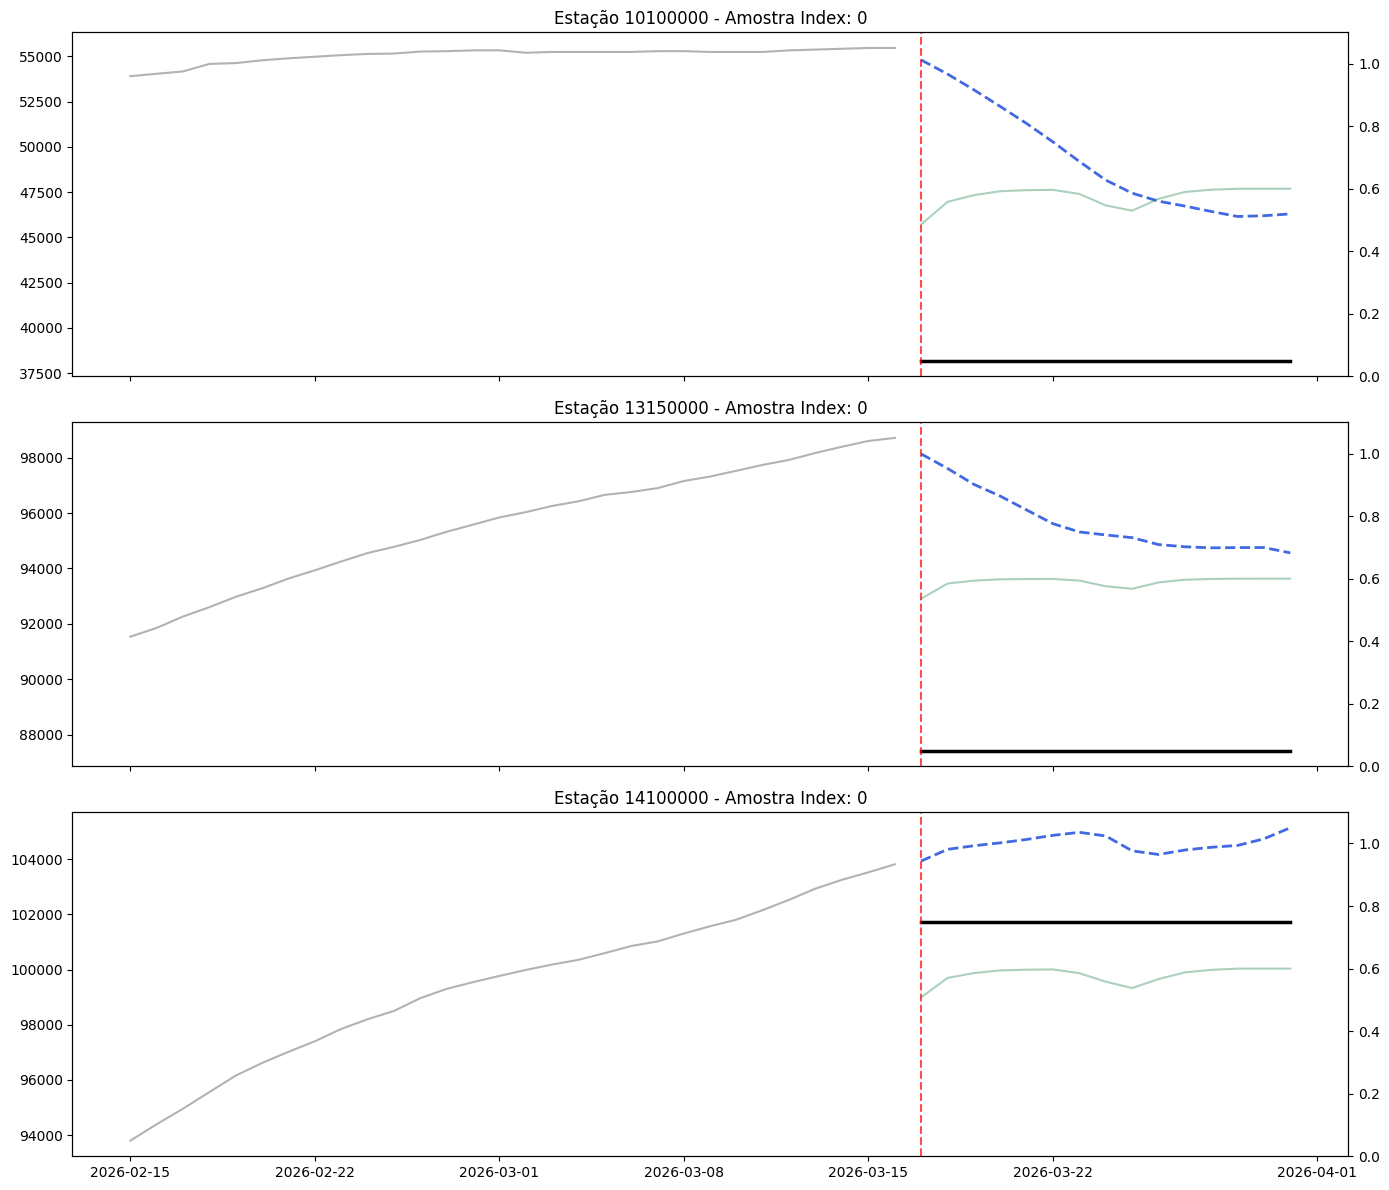

In [8]:
figs = plot_predictions_with_context(
    preds=preds,
    obs=obs,
    stations=meta["stations"],
    df=combined_df,
    forecast_dates=dates,
    n_samples=1,
    context_days=30,
    baseline_last=None,
    g_seq=g_seq,
    show=True # Exibe
)


In [9]:
# Salvar previsões operacionais
'''save_predictions(
    df=df_preds,
    experiment_name=experiment_name,
    mode="operational"
)'''

for fig in figs:
    # Salvar plots operacionais
    save_plot(
        fig=fig,
        experiment_name=experiment_name,
        mode="operational",
        name="operational_forecast.png"
    )

💾 Plot salvo (operational): exp_009_Improve_model_performance_autoregressive_climate_skip_gate/predictions_operational/plots/operational_forecast.png
